In [3]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt


def optimise_overnight_charging(df,
                                datetime_col="Datetime",
                                price_col="Price",
                                load_col="Load",
                                capacity_kw=1500,   # 1.5 MW = 1500 kW
                                output_file="optimised_bus_charging.xlsx"):

    df = df.copy()
    df[datetime_col] = pd.to_datetime(df[datetime_col], dayfirst=True)
    df = df.sort_values(datetime_col).reset_index(drop=True)

    # -----------------------------
    # Convert units properly
    # -----------------------------
    interval_hours = 0.5

    df["load_mwh"] = df[load_col]  / 1000  # kW → MWh

    capacity_mwh = capacity_kw  / 1000

    # -----------------------------
    # Overnight window
    # -----------------------------
    def is_overnight(ts):
        t = ts.time()
        return (t >= pd.to_datetime("17:30").time()) or (t <= pd.to_datetime("04:30").time())

    df["overnight"] = df[datetime_col].apply(is_overnight)

    idx = df.index[df["overnight"]].to_numpy()

    prices = df.loc[idx, price_col].values
    original_energy = df.loc[idx, "load_mwh"].values

    total_energy = original_energy.sum()

    # -----------------------------
    # Optimisation variable (MWh per interval)
    # -----------------------------
    x = cp.Variable(len(idx))

    constraints = [
        cp.sum(x) == total_energy,
        x >= 0,
        x <= capacity_mwh
    ]

    objective = cp.Minimize(prices @ x)

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP)

    if x.value is None:
        raise ValueError("Optimisation failed")

    # -----------------------------
    # Store results
    # -----------------------------
    df["optimised_mwh"] = df["load_mwh"]
    df.loc[idx, "optimised_mwh"] = x.value

    # Convert back to kW for plotting
    df["optimised_kw"] = df["optimised_mwh"] * 1000

    # -----------------------------
    # COST (correct units)
    # -----------------------------
    df["original_cost"] = df["load_mwh"] * df[price_col]
    df["optimised_cost"] = df["optimised_mwh"] * df[price_col]

    # cumulative energy (MWh)
    df["cum_original_mwh"] = df["load_mwh"].cumsum()
    df["cum_optimised_mwh"] = df["optimised_mwh"].cumsum()

    # -----------------------------
    # Summary
    # -----------------------------
    summary = pd.DataFrame([{
        "original_cost": df["original_cost"].sum(),
        "optimised_cost": df["optimised_cost"].sum(),
        "savings": df["original_cost"].sum() - df["optimised_cost"].sum(),
        "total_energy_mwh": total_energy
    }])

    # -----------------------------
    # Export
    # -----------------------------
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        df.to_excel(writer, sheet_name="profile", index=False)
        summary.to_excel(writer, sheet_name="summary", index=False)

    # -----------------------------
    # Plot: load
    # -----------------------------
    plt.figure(figsize=(14, 6))
    plt.plot(df[datetime_col], df[load_col], label="Original kW")
    plt.plot(df[datetime_col], df["optimised_kw"], label="Optimised kW")
    plt.axhline(capacity_kw, linestyle="--", alpha=0.5, label="Capacity (kW)")
    plt.title("Overnight Charging Profile (Power)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot: cumulative energy
    # -----------------------------
    plt.figure(figsize=(14, 6))
    plt.plot(df[datetime_col], df["cum_original_mwh"], label="Original MWh")
    plt.plot(df[datetime_col], df["cum_optimised_mwh"], label="Optimised MWh")
    plt.title("Cumulative Energy Delivered")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Cost comparison
    # -----------------------------
    plt.figure(figsize=(8, 5))
    plt.bar(["Original", "Optimised"],
            [df["original_cost"].sum(), df["optimised_cost"].sum()])
    plt.title("Charging Cost (£)")
    plt.tight_layout()
    plt.show()

    return df, summary

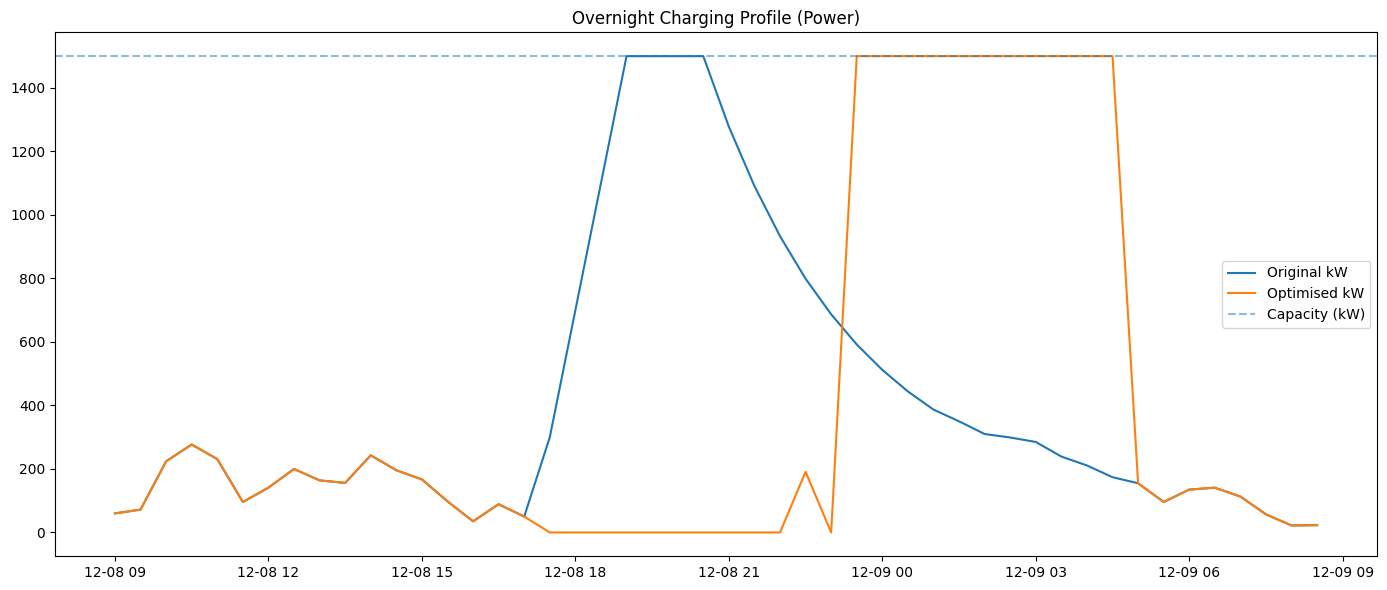

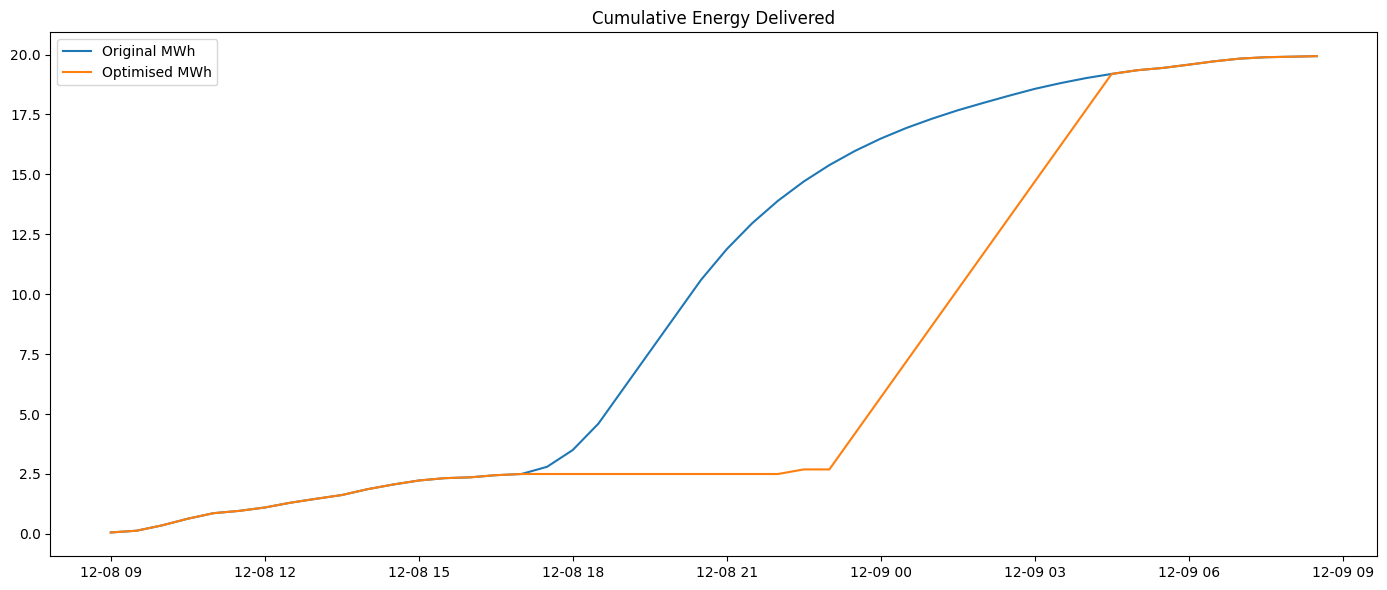

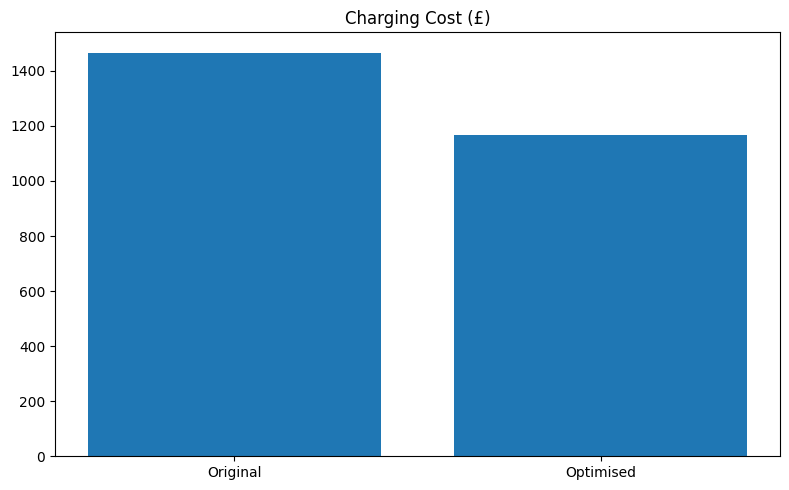

   original_cost  optimised_cost    savings  total_energy_mwh
0     1466.46925      1165.45627  301.01298            16.691


In [4]:
df = pd.read_csv("/content/Input_dec.csv")

df_opt, results = optimise_overnight_charging(df)

print(results)

df_opt.to_csv("/content/Output_dec.csv")